# ANN -  DEEP Learning - Concrete Compressive Strength - Regression  & Classification

#### Concrete is crucial in civil engineering, with compressive strength influenced by its ingredients and curing time. This project uses machine learning, including regression and classification methods, to predict concrete strength and categorize its properties, enhancing construction practices and material optimization.

## Importing necessary libraries

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import (LinearRegression, LogisticRegression,
                                  SGDRegressor, Ridge, Lasso, ElasticNet)
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier,
                               AdaBoostRegressor, AdaBoostClassifier)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier, RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, ExtraTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
# Loading the dataset
df = pd.read_excel('Concrete_Data.xls')
df.columns = ['Cement', 'Slag', 'FlyAsh', 'Water', 'Plasticizer', 'CoarseAgg', 'FineAgg', 'Age', 'Strength']

In [6]:
df.head()

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [7]:
df.tail()

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.401235


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cement       1030 non-null   float64
 1   Slag         1030 non-null   float64
 2   FlyAsh       1030 non-null   float64
 3   Water        1030 non-null   float64
 4   Plasticizer  1030 non-null   float64
 5   CoarseAgg    1030 non-null   float64
 6   FineAgg      1030 non-null   float64
 7   Age          1030 non-null   int64  
 8   Strength     1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [9]:
df.shape

(1030, 9)

In [10]:
df.isnull().sum()

Cement         0
Slag           0
FlyAsh         0
Water          0
Plasticizer    0
CoarseAgg      0
FineAgg        0
Age            0
Strength       0
dtype: int64

## Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.17,104.51,102.00,192.38,272.90,350.00,540.0
Slag,1030.0,73.90,86.28,0.00,0.00,22.00,142.95,359.4
FlyAsh,1030.0,54.19,64.00,0.00,0.00,0.00,118.27,200.1
Water,1030.0,181.57,21.36,121.75,164.90,185.00,192.00,247.0
Plasticizer,1030.0,6.20,5.97,0.00,0.00,6.35,10.16,32.2
CoarseAgg,1030.0,972.92,77.75,801.00,932.00,968.00,1029.40,1145.0
FineAgg,1030.0,773.58,80.18,594.00,730.95,779.51,824.00,992.6
Age,1030.0,45.66,63.17,1.00,7.00,28.00,56.00,365.0
Strength,1030.0,35.82,16.71,2.33,23.71,34.44,46.14,82.6


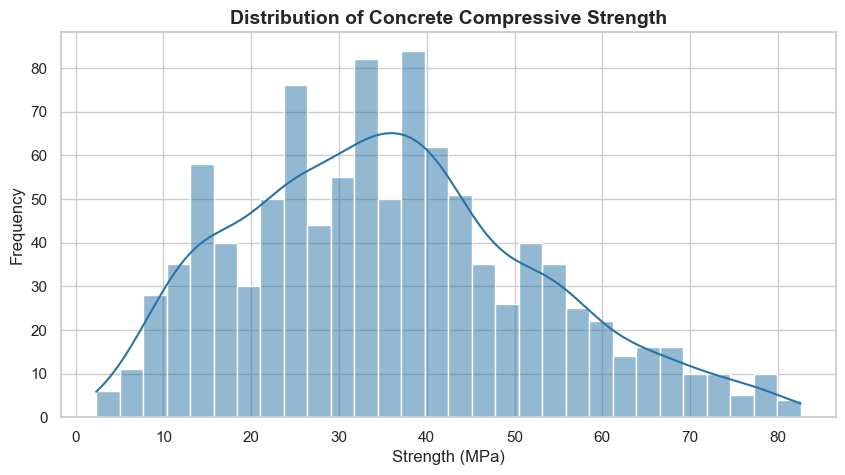

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Strength'], kde=True, bins=30, color='#2874A6')
plt.title('Distribution of Concrete Compressive Strength', fontsize=14, fontweight='bold')
plt.xlabel('Strength (MPa)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

#### The target variable (Strength) follows a roughly normal distribution ranging from ~2 MPa to ~82 MPa, with a mean near 35 MPa. The slight right skew indicates a minority of high-performance mixes. No transformation is needed before modeling.

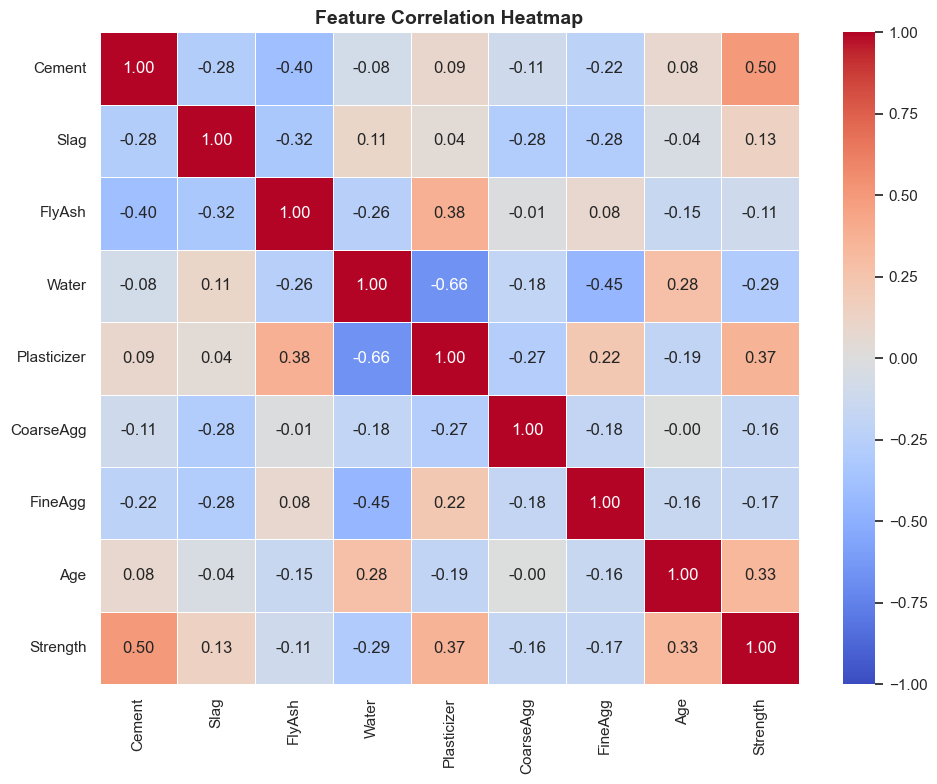

In [15]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Key correlations with target **Strength**:
- **Cement (+0.50):** The strongest positive predictor — higher cement content increases compressive strength.
- **Water (−0.29):** Higher water content weakens the mix, consistent with the water-cement ratio principle in concrete science.
- **Age (+0.33):** Concrete continues to gain strength over time as cement hydration progresses.
- **Superplasticizer (+0.37):** Enables lower water-cement ratios without losing workability, indirectly boosting strength.

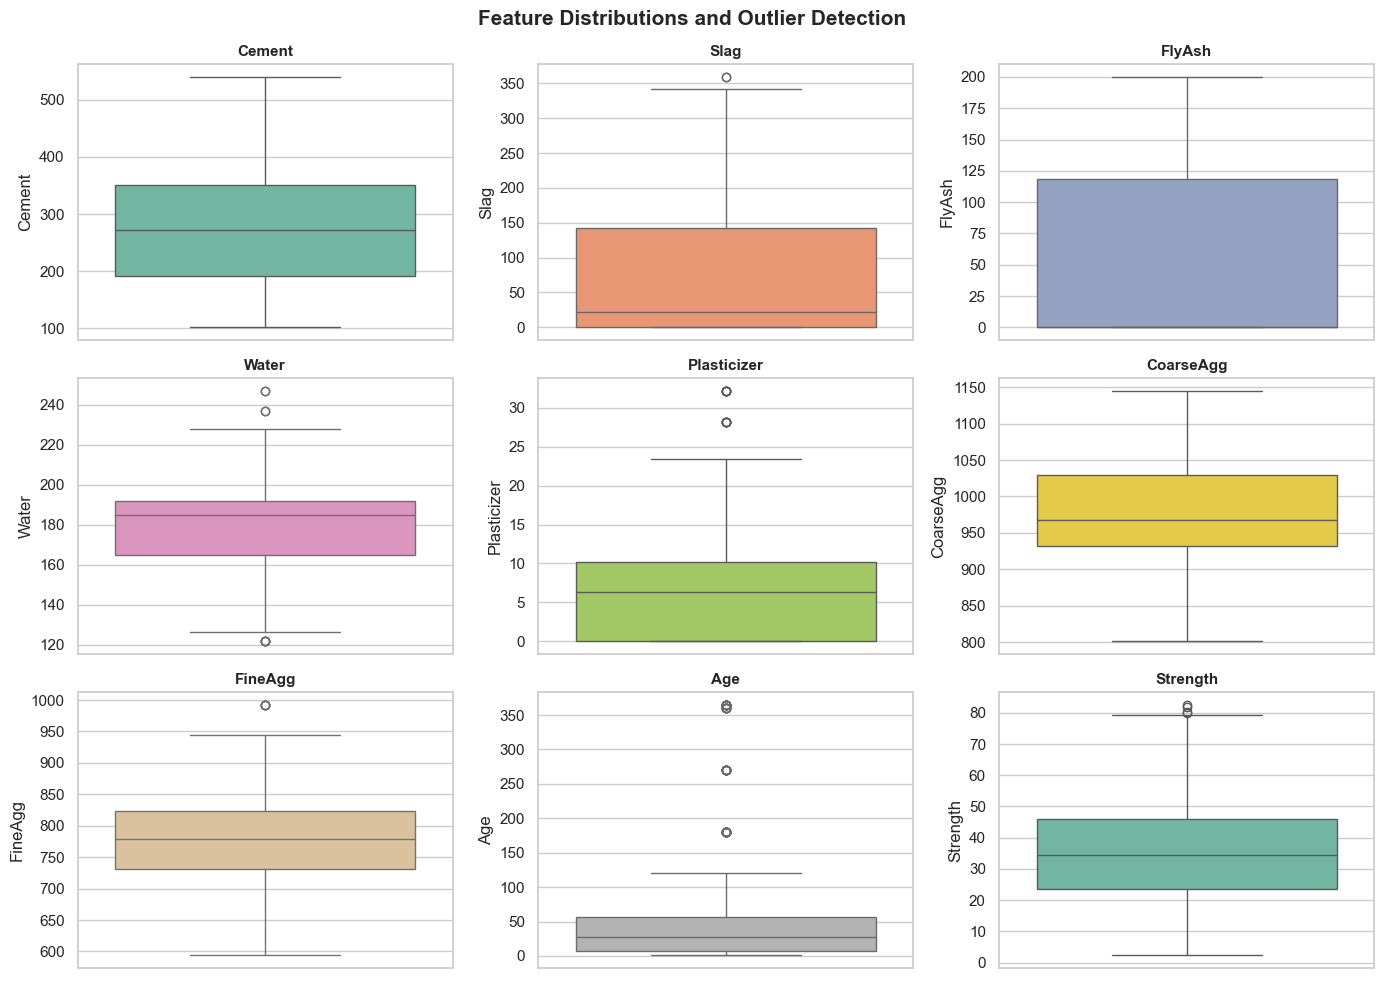

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
palette = sns.color_palette("Set2", len(df.columns))

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color=palette[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions and Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Outliers are present across most features. Key observations:
- **Age** has the most extreme outliers — some concrete samples were tested at 365 days versus the standard 28-day benchmark.
- **Fly Ash** and **Plasticizer** contain many zero values, representing mixes that omit these additives entirely.
- **Cement** and **Water** show compact distributions with few outliers, reflecting well-controlled mix designs.

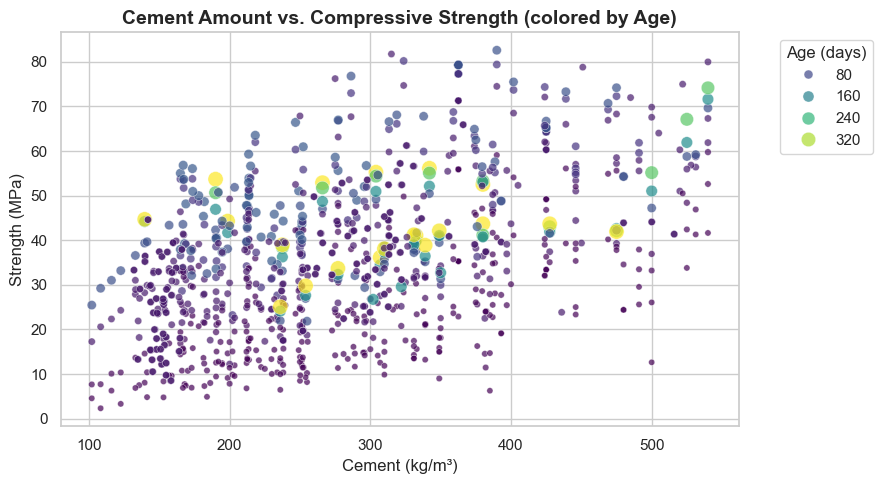

In [19]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Cement', y='Strength', data=df,
                hue='Age', palette='viridis', alpha=0.7,
                size='Age', sizes=(20, 120))
plt.title('Cement Amount vs. Compressive Strength (colored by Age)', fontsize=14, fontweight='bold')
plt.xlabel('Cement (kg/m³)', fontsize=12)
plt.ylabel('Strength (MPa)', fontsize=12)
plt.legend(title='Age (days)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Both **cement content** and **curing age** are positively correlated with strength. High-cement, older samples (brighter points) consistently reach the highest MPa values. However, the wide vertical spread at any given cement level confirms that other variables — water ratio, slag, fly ash — also contribute significantly, which motivates the multi-feature ML approach used in this project.

In [21]:
# Separating feature and target variable
x = df[['Cement', 'Slag', 'FlyAsh', 'Water', 'Plasticizer', 'CoarseAgg', 'FineAgg', 'Age']]
y = df['Strength']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Regression Models

In [25]:
def algo_test(x, y):
    algos = [
        LinearRegression(), Ridge(), Lasso(), ElasticNet(),
        SGDRegressor(), ExtraTreeRegressor(), RandomForestRegressor(),
        GradientBoostingRegressor(), AdaBoostRegressor(),
        KNeighborsRegressor(), DecisionTreeRegressor(),
        XGBRegressor(), SVR(), MLPRegressor()
    ]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree',
        'Random Forest', 'Gradient Boosting', 'AdaBoost',
        'KNeighbors', 'Decision Tree', 'XGBRegressor', 'SVR', 'MLP'
    ]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

    sc = StandardScaler()
    x_train_s = sc.fit_transform(x_train)
    x_test_s  = sc.transform(x_test)

    # Distance / gradient-based models require scaled input
    scale_needed = {'SGD', 'KNeighbors', 'SVR', 'MLP', 'Ridge', 'Lasso', 'ElasticNet'}

    r_squared, rmse, mae = [], [], []
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

    for name, algo in zip(algo_names, algos):
        xt = x_train_s if name in scale_needed else x_train
        xv = x_test_s  if name in scale_needed else x_test
        p  = algo.fit(xt, y_train).predict(xv)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p) ** 0.5)
        mae.append(mean_absolute_error(y_test, p))

    result.R_Squared = r_squared
    result.RMSE      = rmse
    result.MAE       = mae

    return result.sort_values('R_Squared', ascending=False)

In [26]:
algo_test(x,y)

D:\Anaconda\Anacondaa\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,R_Squared,RMSE,MAE
XGBRegressor,0.923075,4.452198,2.906828
Gradient Boosting,0.880874,5.540436,4.097392
Random Forest,0.879284,5.577290,3.833516
Extra Tree,0.828468,6.648352,4.455570
Decision Tree,0.804574,7.096307,4.461627
AdaBoost,0.777541,7.571231,6.298507
KNeighbors,0.718966,8.509829,6.765329
SVR,0.654696,9.432832,7.515449
SGD,0.629481,9.771170,7.745389
Ridge,0.627564,9.796411,7.751761


In [27]:
# Deep Learning Model
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

D:\Anaconda\Anacondaa\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
nn_model.fit(x_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

nn_mse, nn_mae = nn_model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Neural Network: MSE={nn_mse:.2f}, MAE={nn_mae:.2f}")

Neural Network: MSE=33.96, MAE=4.48


### Classification Models

In [30]:
def green_classifier(s):
    return "green" if (s.Slag + s.FlyAsh >= 150.0) or (s.Plasticizer >= 10.0) else "n/a"

def strength_classifier(x):
    if x < 17.0:
        return "non-structural"
    elif x < 28.0:
        return "residential"
    elif x < 70.0:
        return "commercial"
    else:
        return "high-strength"

df['Green'] = df.apply(green_classifier, axis=1)
df['ConcreteClass'] = df['Strength'].apply(strength_classifier)
df.drop('Strength', axis=1, inplace=True)

In [31]:
le_green = LabelEncoder()
df['Green'] = le_green.fit_transform(df['Green'])

In [32]:
x_class = df.drop(['ConcreteClass'], axis=1)
y_class = df['ConcreteClass']

In [33]:
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)

In [34]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x_class, y_class_encoded, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
x_train_c_scaled = scaler_c.fit_transform(x_train_c)
x_test_c_scaled  = scaler_c.transform(x_test_c)

In [35]:
classifiers = {
    'Logistic Regression':    LogisticRegression(max_iter=1000),
    'Decision Tree':          DecisionTreeClassifier(),
    'Random Forest':          RandomForestClassifier(),
    'Gradient Boosting':      GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'KNN Classifier':         KNeighborsClassifier(),
    'AdaBoost Classifier':    AdaBoostClassifier()
}

In [36]:
scale_needed_c = {'Support Vector Machine', 'KNN Classifier', 'Logistic Regression'}

for name, model in classifiers.items():
    xt = x_train_c_scaled if name in scale_needed_c else x_train_c
    xv = x_test_c_scaled  if name in scale_needed_c else x_test_c
    model.fit(xt, y_train_c)
    y_pred_c = model.predict(xv)
    print(f"{name}: Accuracy={accuracy_score(y_test_c, y_pred_c):.2f}")

Logistic Regression: Accuracy=0.79
Decision Tree: Accuracy=0.84
Random Forest: Accuracy=0.87
Gradient Boosting: Accuracy=0.87
Support Vector Machine: Accuracy=0.75
KNN Classifier: Accuracy=0.76
AdaBoost Classifier: Accuracy=0.62


D:\Anaconda\Anacondaa\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [37]:
# Deep Learning Model - Classification
nn_model_class = Sequential([
    Dense(128, activation='relu', input_shape=(x_train_c_scaled.shape[1],)),
    Dense(64,  activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

D:\Anaconda\Anacondaa\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
nn_model_class.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = nn_model_class.fit(x_train_c_scaled, y_train_c, epochs=100, batch_size=32, verbose=0)

In [39]:
nn_loss, nn_accuracy = nn_model_class.evaluate(x_test_c_scaled, y_test_c, verbose=0)
print(f"Neural Network Classifier: Accuracy={nn_accuracy:.2f}")

Neural Network Classifier: Accuracy=0.84


## Conclusion
#### This project explored machine learning techniques for predicting concrete compressive strength and classifying concrete types based on material composition.

#### Regression models like XGBoost and Gradient Boosting delivered the best predictions, with XGBoost achieving the highest R² score. Deep learning (ANN) also showed competitive performance.
#### Classification models effectively categorized concrete into strength classes, with Random Forest and Gradient Boosting achieving the highest accuracy.
#### Feature importance analysis highlighted cement content, water ratio, and curing age as key factors influencing compressive strength.
#### These findings demonstrate how AI can optimize material selection and quality control in civil engineering, paving the way for smarter construction practices.